# Exploratory Data Analysis (EDA)

In [1]:
# Importing necessary libraries
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm # for progress bar
import torchaudio
plt.rcParams['figure.dpi'] = 120

In [2]:
# Configurations
DATA_ROOT = Path('../data/raw/messy_mashup/')
GENRES_PATH = DATA_ROOT / "genres_stems"
ESC50_PATH = DATA_ROOT / "ESC-50-master"
MASHUPS_PATH = DATA_ROOT / "mashups"

GENRES=["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
STEM_FILES=["vocals.wav", "drums.wav", "bass.wav", "other.wav"]

RANDOM_SEED = 42
SR = 22500
np.random.seed(RANDOM_SEED)

# Dataset Structure & Integrity
- Check the directory structure of the dataset.
- Verify that all expected genres and stem files are present.
- Check for any missing or corrupted audio files.

In [4]:
# Checking the dataset structure
def validate_dataset_structure():
    print("Root Contents:", list(DATA_ROOT.iterdir()))
    print("Genres Contents:", list(GENRES_PATH.iterdir()))
    print("ESC-50 Contents:", list(ESC50_PATH.iterdir()))
    print("Mashups Count:", len(list(MASHUPS_PATH.glob("*.wav"))))

validate_dataset_structure()

Root Contents: [PosixPath('../data/raw/messy_mashup/genres_stems'), PosixPath('../data/raw/messy_mashup/test.csv'), PosixPath('../data/raw/messy_mashup/ESC-50-master'), PosixPath('../data/raw/messy_mashup/sample_submission.csv'), PosixPath('../data/raw/messy_mashup/mashups')]
Genres Contents: [PosixPath('../data/raw/messy_mashup/genres_stems/country'), PosixPath('../data/raw/messy_mashup/genres_stems/reggae'), PosixPath('../data/raw/messy_mashup/genres_stems/jazz'), PosixPath('../data/raw/messy_mashup/genres_stems/blues'), PosixPath('../data/raw/messy_mashup/genres_stems/rock'), PosixPath('../data/raw/messy_mashup/genres_stems/metal'), PosixPath('../data/raw/messy_mashup/genres_stems/hiphop'), PosixPath('../data/raw/messy_mashup/genres_stems/disco'), PosixPath('../data/raw/messy_mashup/genres_stems/pop'), PosixPath('../data/raw/messy_mashup/genres_stems/classical')]
ESC-50 Contents: [PosixPath('../data/raw/messy_mashup/ESC-50-master/meta'), PosixPath('../data/raw/messy_mashup/ESC-50-ma

In [4]:
# Genre & Song Count Check
def check_genre_song_counts():
    genre_counts = {}
    for genre_dir in GENRES_PATH.iterdir():
        if genre_dir.is_dir():
            songs = list(genre_dir.iterdir())
            genre_counts[genre_dir.name] = len(songs)
    
    df=pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Song Count'])
    return df

genre_df = check_genre_song_counts()
genre_df

,Genre,Song Count
0,country,100
1,reggae,100
2,jazz,100
3,blues,100
4,rock,100
5,metal,100
6,hiphop,100
7,disco,100
8,pop,100
9,classical,100


In [5]:
# Checking Stem Consistency for each song
EXPECTED_STEMS = {"drums.wav", "vocals.wav", "bass.wav", "other.wav"}

def validate_stems():
    errors = []

    for genre_dir in GENRES_PATH.iterdir():
        for song_dir in genre_dir.iterdir():
            if song_dir.is_dir():
                stems = {f.name for f in song_dir.glob("*.wav")}
                if stems != EXPECTED_STEMS:
                    errors.append((genre_dir.name, song_dir.name, stems))

    return errors


stem_errors = validate_stems()
print("Stem Errors:", stem_errors)

Stem Errors: []


- All songs have exactly the 4 expected stem files. Dataset is complete.

In [18]:
# Sample Rate Check for all stems
def check_sample_rates():
    sr_found = set()
    for genre in GENRES:
        song = next((GENRES_PATH / genre).iterdir()) # Get 1st song from the genre
        for stem in STEM_FILES:
            stem_path = song / stem
            if stem_path.exists():
                info = torchaudio.info(str(stem_path))
                sr_found.add(info.sample_rate)

    return sr_found
sr_found = check_sample_rates()

print(f'Native sample rates found: {sr_found}')

Native sample rates found: {44100}


- The Sample rate is 44100 hz
But we will resample to 22500 hz for faster processing and to focus on the most relevant frequency range for genre classification.

## Audio Statistics and Visualization

### Extracting Audio Statistics

**Features extracted:**
- **Duration**: total length in seconds — tells if we need padding/cropping
- **RMS Energy**: A measure of the average power of the audio signal, which can indicate loudness.
- **Silence Ratio**: fraction of near-silent frames
- **Zero Crossing Rate (ZCR)**: The rate at which the audio signal changes sign, which can indicate the noisiness or percussiveness of the audio.
- **Spectral Centroid**: The "center of mass" of the spectrum, which can indicate the brightness of the sound. i.e., frequency.
- **Spectral Bandwidth**: how spread out the frequency content is
- **Spectral Rolloff**: frequency below which 85% of energy is contained
- **Tempo**: estimated BPM

In [49]:
# Helper function to extract audio statistics
def extract_audio_stats(file_path: Path):
    # Extract a set of low-level audio features from a single wav file.
    try:
        y, sr = librosa.load(file_path, sr=None)

        # Basic audio properties
        duration = librosa.get_duration(y=y, sr=sr)
        rms = np.mean(librosa.feature.rms(y=y))
        
        
        # Silence ratio - Proportion of silent frames in the audio
        intervals = librosa.effects.split(y, top_db=30)
        non_silent_samples = sum(end - start for start, end in intervals)
        silence_ratio = 1 - (non_silent_samples / len(y))


        # Time domain feature
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        # Frequency domain feature
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        stats = {
            "sample_rate": sr,
            "duration": duration,
            "rms": rms,
            "zcr": zcr,
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "spectral_rolloff": rolloff,
            "silence_ratio": silence_ratio,
            "tempo": tempo[0] if isinstance(tempo, np.ndarray) else tempo
        }

        return stats

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


In [50]:
# Get stats for random 10 songs in each genre
def analyze_genre_audio_stats():
    stats = []
    for genre_dir in GENRES_PATH.iterdir():

        song_dirs = list(genre_dir.iterdir())
        #random select 10 songs for analysis
        sampled_songs = np.random.choice(song_dirs, size=min(10, len(song_dirs)), replace=False)

        for song_dir in tqdm(sampled_songs, desc=f"Processing {genre_dir.name}", unit="song"):
            
            if song_dir.is_dir():
                for stem_file in song_dir.glob("*.wav"):
                    audio_stats = extract_audio_stats(stem_file)
                    if audio_stats:
                        audio_stats["genre"] = genre_dir.name
                        audio_stats["song"] = song_dir.name
                        audio_stats["stem"] = stem_file.name
                        stats.append(audio_stats)

    return pd.DataFrame(stats)

audio_stats_df = analyze_genre_audio_stats()
print(f'Collected {len(audio_stats_df)} records across {audio_stats_df["genre"].nunique()} genres')

Processing country:   0%|          | 0/10 [00:00<?, ?song/s]

Processing classical: 100%|██████████| 10/10 [00:13<00:00,  1.31s/song]

Collected 400 records across 10 genres


In [23]:
audio_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_rate         400 non-null    int64  
 1   duration            400 non-null    float64
 2   rms                 400 non-null    float32
 3   zcr                 400 non-null    float64
 4   spectral_centroid   400 non-null    float64
 5   spectral_bandwidth  400 non-null    float64
 6   spectral_rolloff    400 non-null    float64
 7   silence_ratio       400 non-null    float64
 8   tempo               400 non-null    object 
 9   genre               400 non-null    object 
 10  song                400 non-null    object 
 11  stem                400 non-null    object 
dtypes: float32(1), float64(6), int64(1), object(4)
memory usage: 36.1+ KB


In [24]:
audio_stats_df.describe()

,sample_rate,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,silence_ratio
count,400.0,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000
mean,44100.0,30.017748,4.517809e-02,0.073646,2283.289086,1776.868472,3880.510277,0.228953
std,0.0,0.051762,3.529260e-02,0.065192,1673.586559,850.279007,2675.765804,0.277177
min,44100.0,29.995828,3.575489e-09,0.000009,15.095237,9.480842,26.912340,0.000000
25%,44100.0,30.000181,2.068801e-02,0.009979,867.801543,1025.585921,1559.991816,0.014508
50%,44100.0,30.013333,4.028123e-02,0.060968,2039.421814,1829.964856,3776.841956,0.118372
75%,44100.0,30.013333,6.613822e-02,0.112373,3395.443570,2433.491601,6225.112880,0.349028
max,44100.0,30.370975,2.119532e-01,0.318604,8524.131300,4483.333515,13349.969751,0.994584


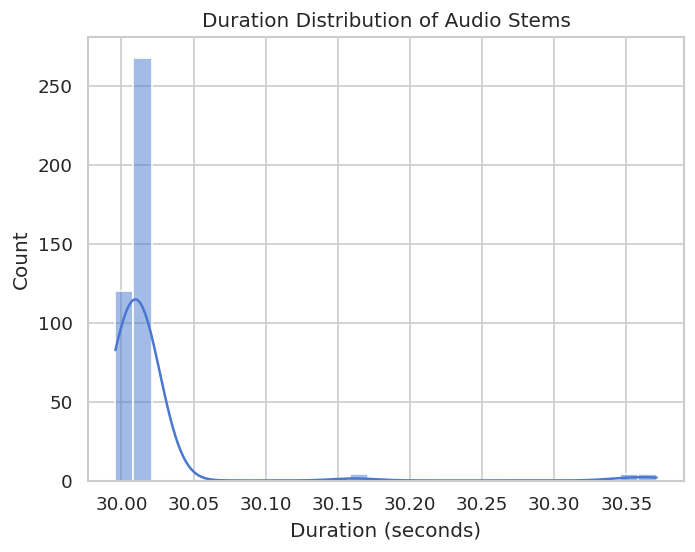

In [30]:
# Duration Distribution
sns.histplot(audio_stats_df['duration'], bins=30, kde=True)
plt.title("Duration Distribution of Audio Stems")
plt.xlabel("Duration (seconds)")
plt.show()

- This shows most of the songs are 30 seconds long, with a few deviations.

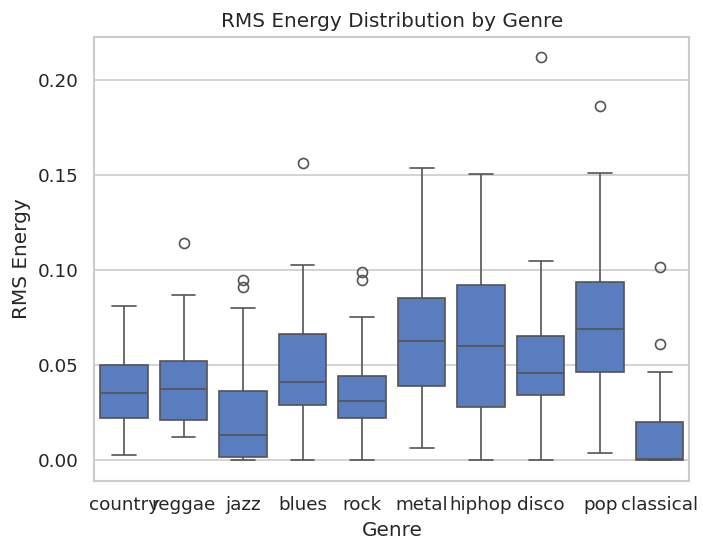

In [ ]:
# RMS Energy by Genre
sns.boxplot(x='genre', y='rms', data=audio_stats_df)
plt.title("RMS Energy Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("RMS Energy")
plt.show()

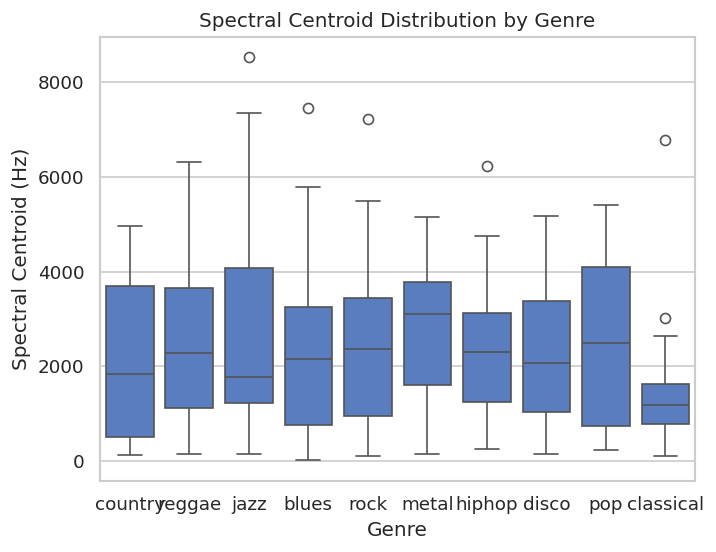

In [37]:
# spectral centroid by genre
sns.boxplot(x='genre', y='spectral_centroid', data=audio_stats_df)
plt.title("Spectral Centroid Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Spectral Centroid (Hz)")
plt.show()

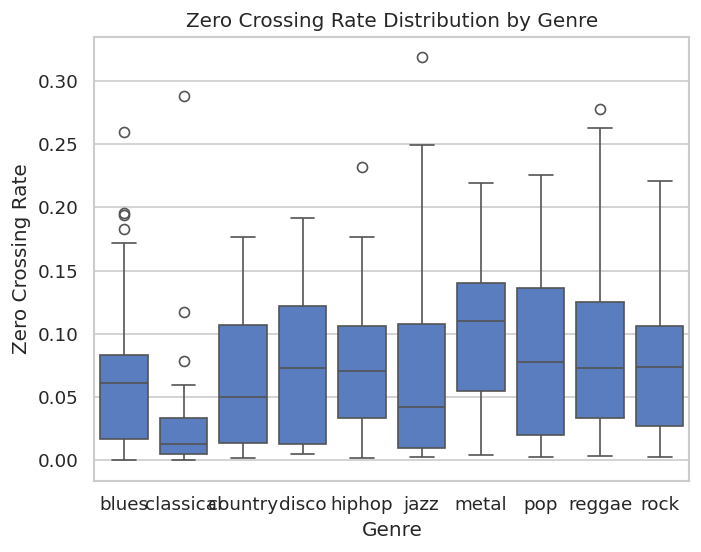

In [45]:
# zcr by genre
sns.boxplot(x='genre', y='zcr', data=audio_stats_df)
plt.title("Zero Crossing Rate Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Zero Crossing Rate")
plt.show()

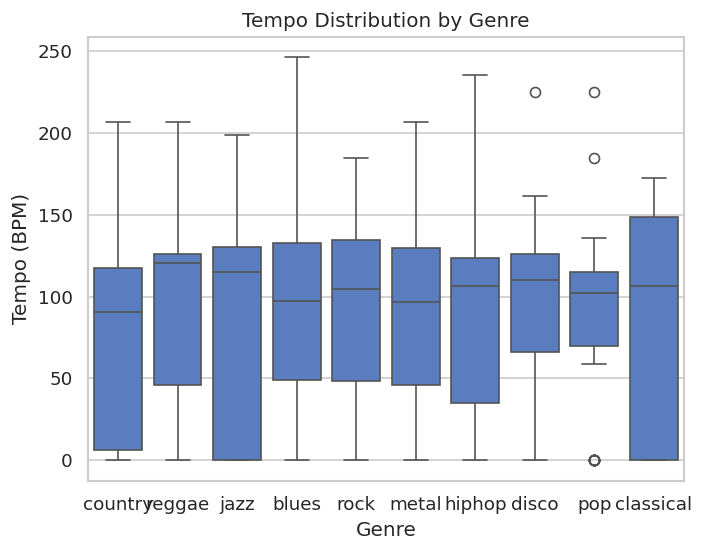

In [51]:
# Tempo by genre
sns.boxplot(x='genre', y='tempo', data=audio_stats_df)
plt.title("Tempo Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Tempo (BPM)")
plt.show()

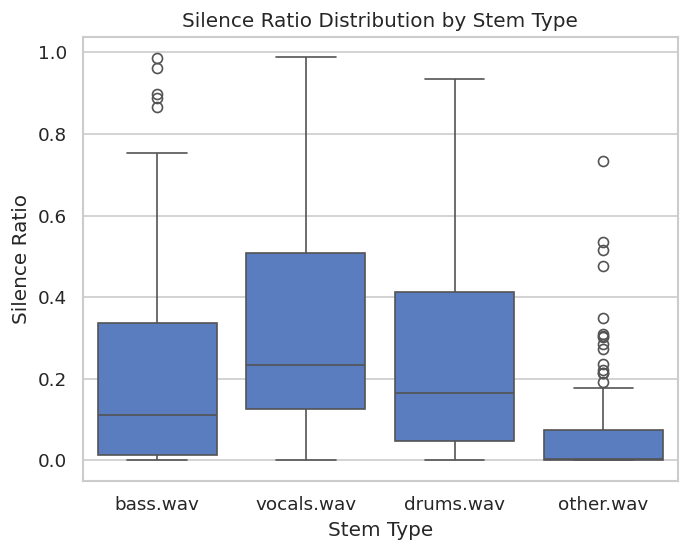

In [53]:
# Silence ratio by stem type
sns.boxplot(x='stem', y='silence_ratio', data=audio_stats_df)
plt.title("Silence Ratio Distribution by Stem Type")
plt.xlabel("Stem Type")
plt.ylabel("Silence Ratio")
plt.show()

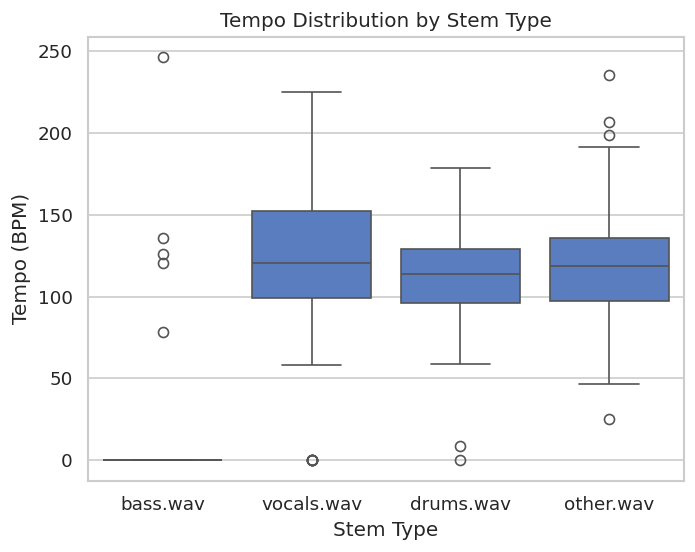

In [56]:
# Tempo by stem type
sns.boxplot(x='stem', y='tempo', data=audio_stats_df)
plt.title("Tempo Distribution by Stem Type")
plt.xlabel("Stem Type")
plt.ylabel("Tempo (BPM)")
plt.show()

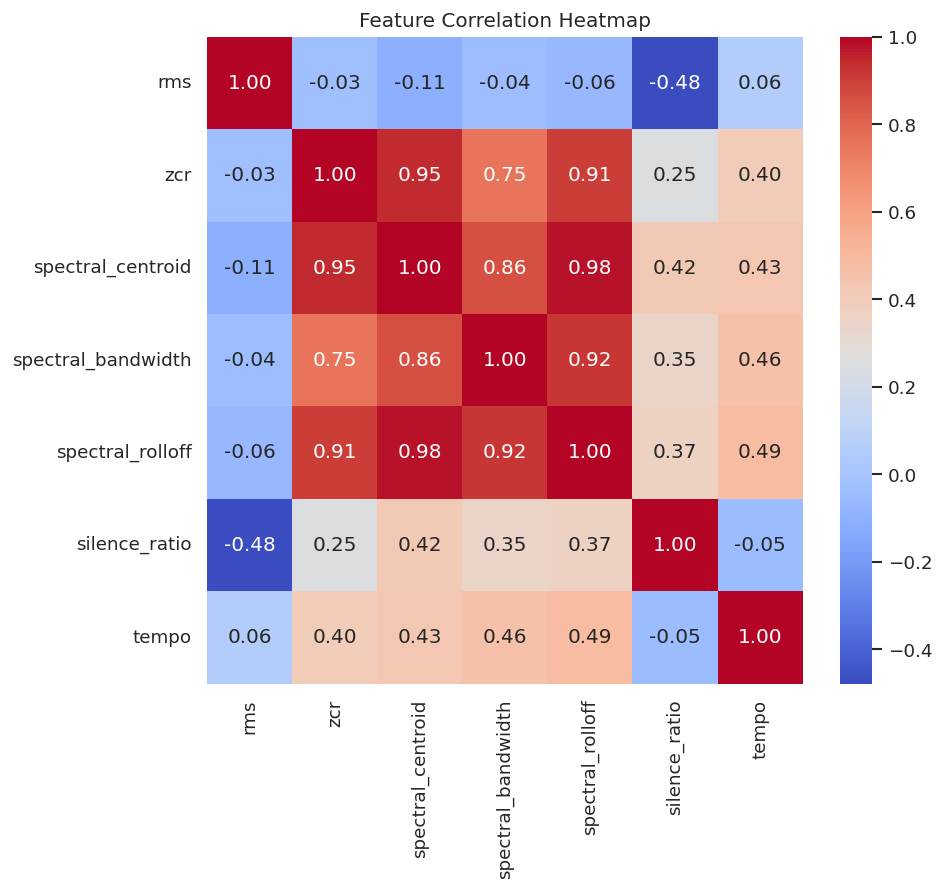

In [69]:
# Feature Correlation Heatmap
feat_cols = ['rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'silence_ratio', 'tempo']
corr_matrix = audio_stats_df[feat_cols].corr()
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

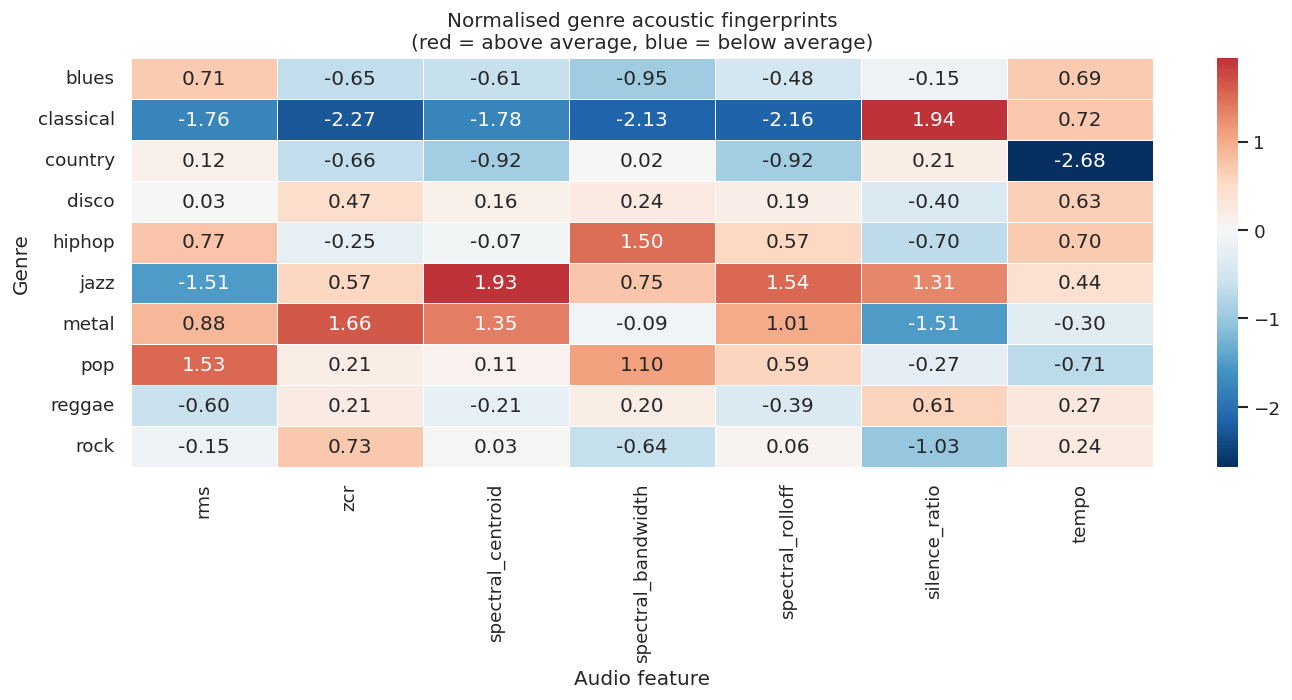

In [68]:
# Genre means heatmap (normalised)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#Mean by genre for each feature
genre_means = audio_stats_df.groupby('genre')[feat_cols].mean()
genre_means_norm = pd.DataFrame(
    scaler.fit_transform(genre_means),
    index=genre_means.index,
    columns=genre_means.columns
)
plt.subplots(figsize=(12, 6))
sns.heatmap(genre_means_norm, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Normalised genre acoustic fingerprints\n(red = above average, blue = below average)')
plt.xlabel('Audio feature')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# Spectogram Analysis

In [3]:
# Helper to load and mix all 4 stems from a randomly selected song of the given genre
def load_mashup(genre, sr=SR, duration=10):
    genre_dir = GENRES_PATH / genre
    song_dir = random.choice(list(genre_dir.iterdir()))
    stems = []
    for stem_file in STEM_FILES:
        stem_path = song_dir / stem_file
        if stem_path.exists():
            y, _ = librosa.load(stem_path, sr=sr, duration=duration)
            stems.append(y)
    
    if not stems:
        return None
    
    min_len = min(len(s) for s in stems)
    mixed = sum(s[:min_len] for s in stems)
    return mixed

In [4]:
# Helper to compute log-scaled mel spectrogram
def compute_log_mel(y, sr=SR, n_fft=2048, hop_length=512, n_mels=128):

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,hop_length=hop_length, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

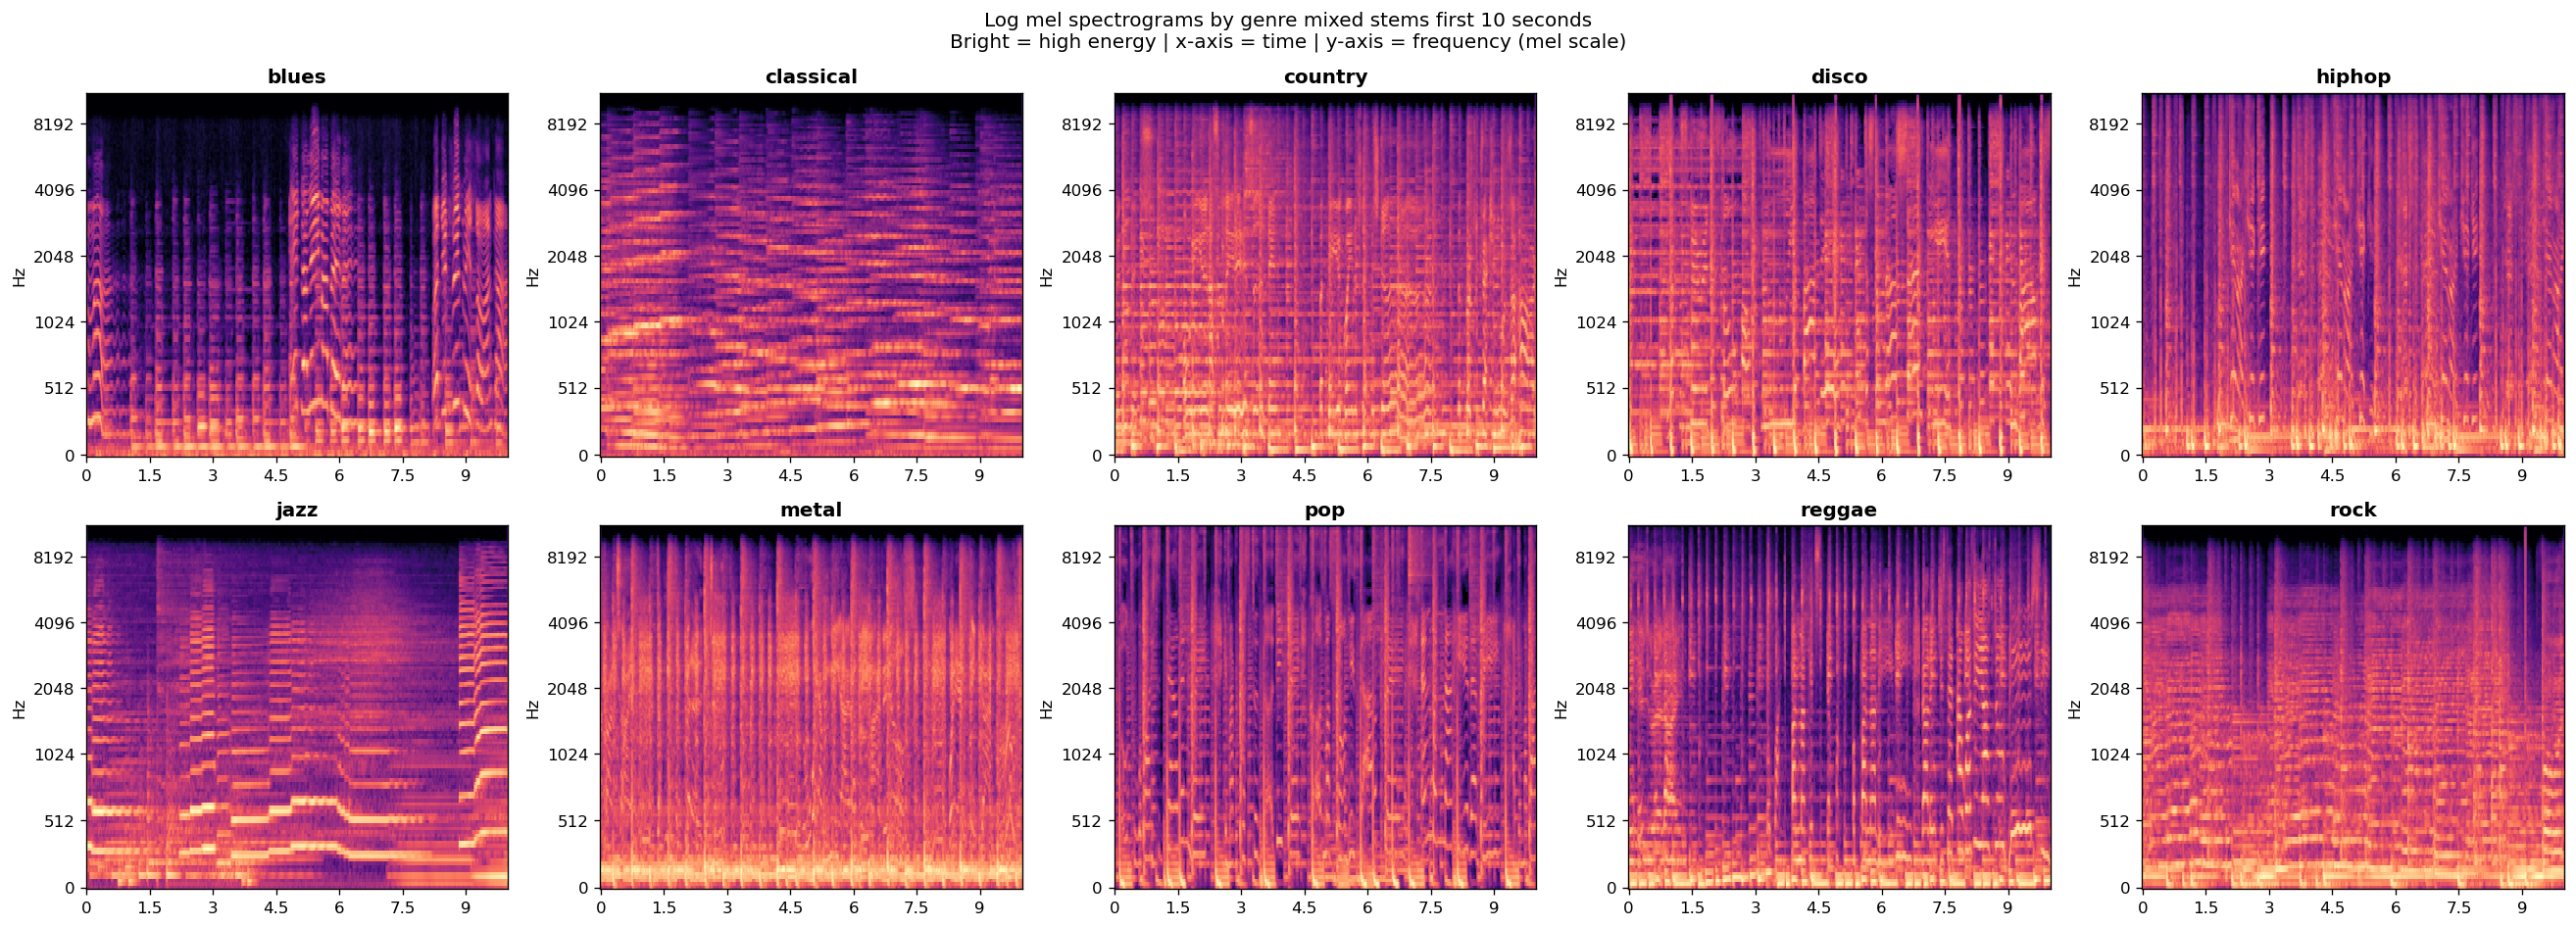

In [9]:
# Comparing spectograms across genres

# Plot one spectrogram per genre
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, genre in enumerate(GENRES):
    mixed=load_mashup(genre)
    S_db = compute_log_mel(mixed)

    librosa.display.specshow(S_db, sr=SR, ax=axes[i], hop_length=512, x_axis='time', y_axis='mel')
    axes[i].set_title(genre, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Log mel spectrograms by genre mixed stems first 10 seconds\n'
             'Bright = high energy | x-axis = time | y-axis = frequency (mel scale)')
plt.tight_layout()
plt.show()

-  We can visually distinguish genres from their spectrograms.

## Noise ESC-50 Data 

In [18]:
# ESC-50 Metadata
noise_metadata_path = ESC50_PATH / "meta"
noise_metadata_df = pd.read_csv(noise_metadata_path / "esc50.csv")
noise_metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


In [19]:
noise_metadata_df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [35]:
ESC50_AUDIO_PATH = ESC50_PATH / "audio"

def analyse_noise():
    stats=[]
    
    audios=list(ESC50_AUDIO_PATH.glob("*.wav"))
    # randomly sample 100 audio files for analysis
    sampled_audios = np.random.choice(audios, size=min(100, len(audios)), replace=False)

    for file_path in tqdm(sampled_audios, desc="Analyzing Noise Files", unit="file"):
        audio_stats = extract_audio_stats(file_path)
        if audio_stats:
            audio_stats["file_name"] = file_path.name
            stats.append(audio_stats)
    return stats

noise_stats_df = pd.DataFrame(analyse_noise())

Analyzing Noise Files: 100%|██████████| 100/100 [00:09<00:00, 10.52file/s]


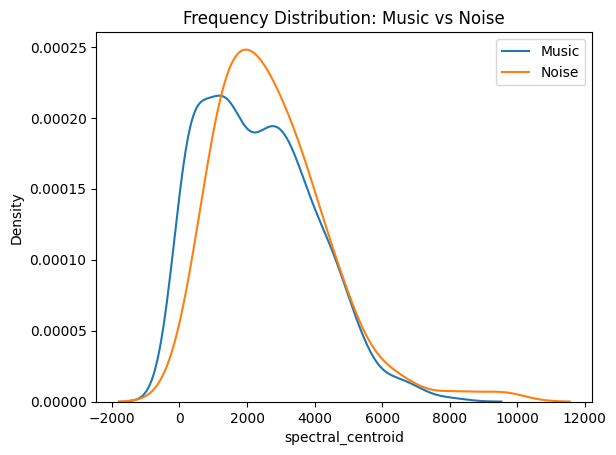

In [37]:
# Compare spectral centroid distributions between music and noise

sns.kdeplot(audio_stats_df["spectral_centroid"], label="Music")
sns.kdeplot(noise_stats_df["spectral_centroid"], label="Noise")
plt.legend()
plt.title("Frequency Distribution: Music vs Noise")
plt.show()